# Notebook 2 – EDA & Feature Engineering

**Tujuan:** Eksplorasi data secara mendalam (EDA) dan dokumentasi 164 fitur yang diekstrak dari setiap board untuk keperluan machine learning.

**Output yang dihasilkan:**
- `outputs/results/nb02_*.png`

**Tahap penelitian:** Tahap 3 (Feature Engineering) & Tahap 4 (Dataset)

> **Prasyarat:** Jalankan `01_data_extraction.ipynb` terlebih dahulu, atau pastikan `data/processed/` sudah ada.

---
## 0. Setup

In [1]:
import sys
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

OUT = ROOT / 'outputs' / 'results'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')
print('Setup selesai.')

Setup selesai.


In [2]:
# Load dataset lengkap
df = pd.read_csv(ROOT / 'data' / 'processed' / 'full.csv')
feature_cols = json.loads((ROOT / 'data' / 'processed' / 'feature_columns.json').read_text())

print(f'Dataset shape : {df.shape}')
print(f'Fitur         : {len(feature_cols)}')
print(f'Target unik   : {df["target_base"].nunique()} kelas')
print(f'\nKolom target yang tersedia:')
for col in ['target', 'target_base', 'target_category', 'label']:
    if col in df.columns:
        print(f'  {col:<18}: {df[col].nunique()} nilai unik')

Dataset shape : (10223, 174)
Fitur         : 164
Target unik   : 35 kelas

Kolom target yang tersedia:
  target            : 67 nilai unik
  target_base       : 35 nilai unik
  target_category   : 5 nilai unik
  label             : 35 nilai unik


---
## 1. Struktur Fitur

In [3]:
# Kelompokkan fitur berdasarkan prefix
def group_features(cols):
    groups = {
        'Hand N (North)':     [c for c in cols if c.startswith('N_')],
        'Hand E (East)':      [c for c in cols if c.startswith('E_')],
        'Hand S (South)':     [c for c in cols if c.startswith('S_')],
        'Hand W (West)':      [c for c in cols if c.startswith('W_')],
        'Partnership NS':     [c for c in cols if c.startswith('ns_')],
        'Partnership EW':     [c for c in cols if c.startswith('ew_')],
        'HCP Advantage':      [c for c in cols if 'advantage' in c],
        'Deal (Dealer)':      [c for c in cols if c.startswith('dealer_')],
        'Deal (Vuln)':        [c for c in cols if c.startswith('vuln_')],
        'Auction':            [c for c in cols if c.startswith('auction_') or c.startswith('opening_')],
    }
    return groups

groups = group_features(feature_cols)

print(f'{'Kelompok Fitur':<25} {'Jumlah':>7}  Contoh')
print('-' * 75)
for name, cols in groups.items():
    examples = ', '.join(cols[:3]) + (' ...' if len(cols) > 3 else '')
    print(f'{name:<25} {len(cols):>7}  {examples}')
print('-' * 75)
print(f'{'TOTAL':<25} {sum(len(v) for v in groups.values()):>7}')

Kelompok Fitur             Jumlah  Contoh
---------------------------------------------------------------------------
Hand N (North)                 24  N_hcp, N_hcp_S, N_len_S ...
Hand E (East)                  24  E_hcp, E_hcp_S, E_len_S ...
Hand S (South)                 24  S_hcp, S_hcp_S, S_len_S ...
Hand W (West)                  24  W_hcp, W_hcp_S, W_len_S ...
Partnership NS                 22  ns_hcp, ns_ltc, ns_controls ...
Partnership EW                 22  ew_hcp, ew_ltc, ew_controls ...
HCP Advantage                   1  hcp_ns_advantage
Deal (Dealer)                   4  dealer_N, dealer_E, dealer_S ...
Deal (Vuln)                     4  vuln_none, vuln_ns, vuln_ew ...
Auction                        15  auction_len, auction_ns_bids, auction_ew_bids ...
---------------------------------------------------------------------------
TOTAL                         164


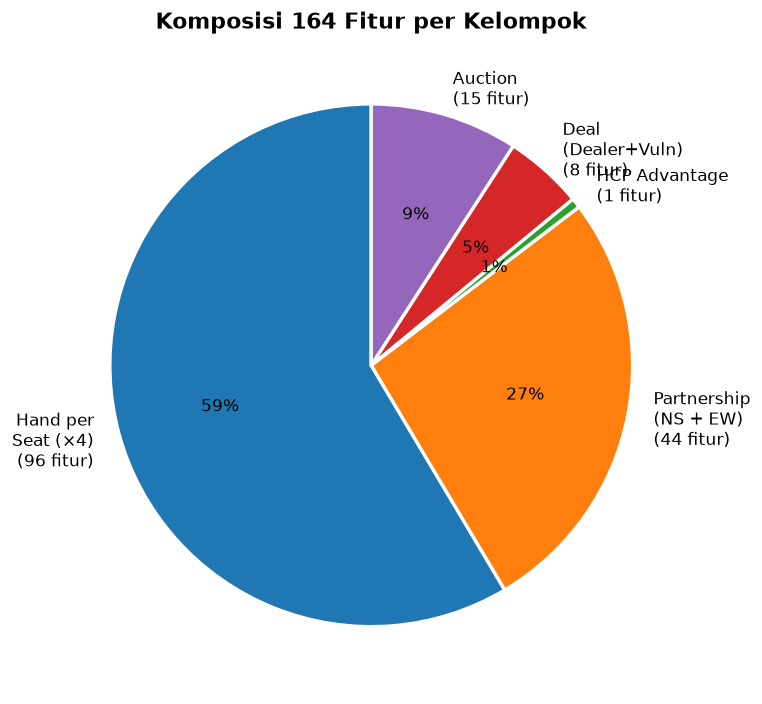

In [4]:
# Pie chart distribusi kelompok fitur
group_summary = {
    'Hand per\nSeat (×4)': sum(len(v) for k, v in groups.items() if k.startswith('Hand')),
    'Partnership\n(NS + EW)': len(groups['Partnership NS']) + len(groups['Partnership EW']),
    'HCP Advantage': len(groups['HCP Advantage']),
    'Deal\n(Dealer+Vuln)': len(groups['Deal (Dealer)']) + len(groups['Deal (Vuln)']),
    'Auction': len(groups['Auction']),
}

fig, ax = plt.subplots(figsize=(7, 6))
pie_cols = sns.color_palette('tab10', len(group_summary))
wedges, texts, autotexts = ax.pie(
    group_summary.values(),
    labels=[f'{k}\n({v} fitur)' for k, v in group_summary.items()],
    colors=pie_cols,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10},
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title(f'Komposisi 164 Fitur per Kelompok', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'nb02_feature_groups.png', bbox_inches='tight')
plt.show()

In [5]:
# Daftar lengkap fitur per kelompok
print('=== DAFTAR FITUR PER KELOMPOK ===')
for group_name, cols in groups.items():
    print(f'\n[{group_name}]  ({len(cols)} fitur)')
    # Tampilkan statistik deskriptif untuk beberapa fitur
    sample_cols = cols[:4]
    stats = df[sample_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2)
    print(stats.to_string())
    if len(cols) > 4:
        print(f'  ... dan {len(cols)-4} fitur lainnya')

=== DAFTAR FITUR PER KELOMPOK ===

[Hand N (North)]  (24 fitur)
      N_hcp  N_hcp_S  N_len_S  N_stopper_S
mean   9.89     2.46     3.26         0.59
std    4.12     2.28     1.37         0.49
min    0.00     0.00     0.00         0.00
max   26.00    10.00     9.00         1.00
  ... dan 20 fitur lainnya

[Hand E (East)]  (24 fitur)
      E_hcp  E_hcp_S  E_len_S  E_stopper_S
mean  10.00     2.49     3.23         0.59
std    4.13     2.29     1.35         0.49
min    0.00     0.00     0.00         0.00
max   26.00    10.00     8.00         1.00
  ... dan 20 fitur lainnya

[Hand S (South)]  (24 fitur)
      S_hcp  S_hcp_S  S_len_S  S_stopper_S
mean  10.10     2.56     3.26         0.60
std    4.19     2.35     1.37         0.49
min    0.00     0.00     0.00         0.00
max   26.00    10.00     8.00         1.00
  ... dan 20 fitur lainnya

[Hand W (West)]  (24 fitur)
      W_hcp  W_hcp_S  W_len_S  W_stopper_S
mean  10.02     2.49     3.25         0.60
std    4.17     2.32     1.38       

---
## 2. EDA – Distribusi HCP

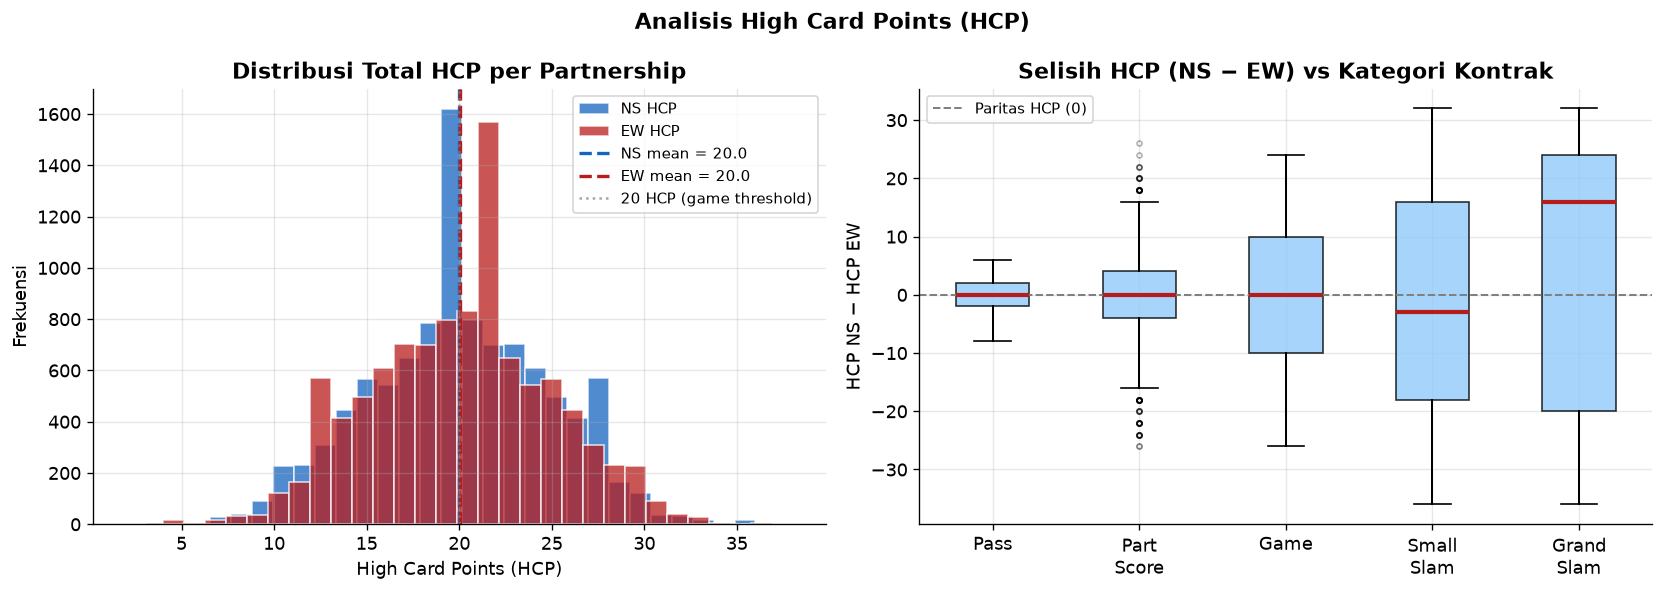

Statistik HCP NS per kategori:
                 mean   std   min   max
target_category                        
Game             20.0   5.3   7.0  32.0
GrandSlam        22.6  11.4   2.0  36.0
Partscore        19.9   2.9   7.0  33.0
Pass             19.9   1.9  16.0  23.0
SmallSlam        19.5   8.6   2.0  36.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Distribusi HCP NS vs EW ────────────────────────────────
ax = axes[0]
ax.hist(df['ns_hcp'], bins=30, alpha=0.75, label='NS HCP', color='#1565C0', edgecolor='white')
ax.hist(df['ew_hcp'], bins=30, alpha=0.75, label='EW HCP', color='#B71C1C', edgecolor='white')
ax.axvline(df['ns_hcp'].mean(), color='#1565C0', linestyle='--', lw=2,
           label=f'NS mean = {df["ns_hcp"].mean():.1f}')
ax.axvline(df['ew_hcp'].mean(), color='#B71C1C', linestyle='--', lw=2,
           label=f'EW mean = {df["ew_hcp"].mean():.1f}')
ax.axvline(20, color='gray', linestyle=':', lw=1.5, alpha=0.7, label='20 HCP (game threshold)')
ax.set_title('Distribusi Total HCP per Partnership', fontweight='bold')
ax.set_xlabel('High Card Points (HCP)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# ── HCP Advantage vs Kategori ──────────────────────────────
ax = axes[1]
cat_order_box = ['Pass', 'Partscore', 'Game', 'SmallSlam', 'GrandSlam']
cat_labels_box = ['Pass', 'Part\nScore', 'Game', 'Small\nSlam', 'Grand\nSlam']
data_box = [df[df['target_category'] == c]['hcp_ns_advantage'].dropna()
            for c in cat_order_box]
bp = ax.boxplot(
    data_box, tick_labels=cat_labels_box, patch_artist=True,
    boxprops=dict(facecolor='#90CAF9', alpha=0.8),
    medianprops=dict(color='#B71C1C', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
)
ax.axhline(0, color='gray', linestyle='--', lw=1.2, label='Paritas HCP (0)')
ax.set_title('Selisih HCP (NS − EW) vs Kategori Kontrak', fontweight='bold')
ax.set_ylabel('HCP NS − HCP EW')
ax.legend(fontsize=9)

plt.suptitle('Analisis High Card Points (HCP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_hcp_analysis.png', bbox_inches='tight')
plt.show()

print('Statistik HCP NS per kategori:')
print(df.groupby('target_category')['ns_hcp'].describe()[['mean','std','min','max']].round(1))

---
## 3. EDA – Suit Fit & Stopper

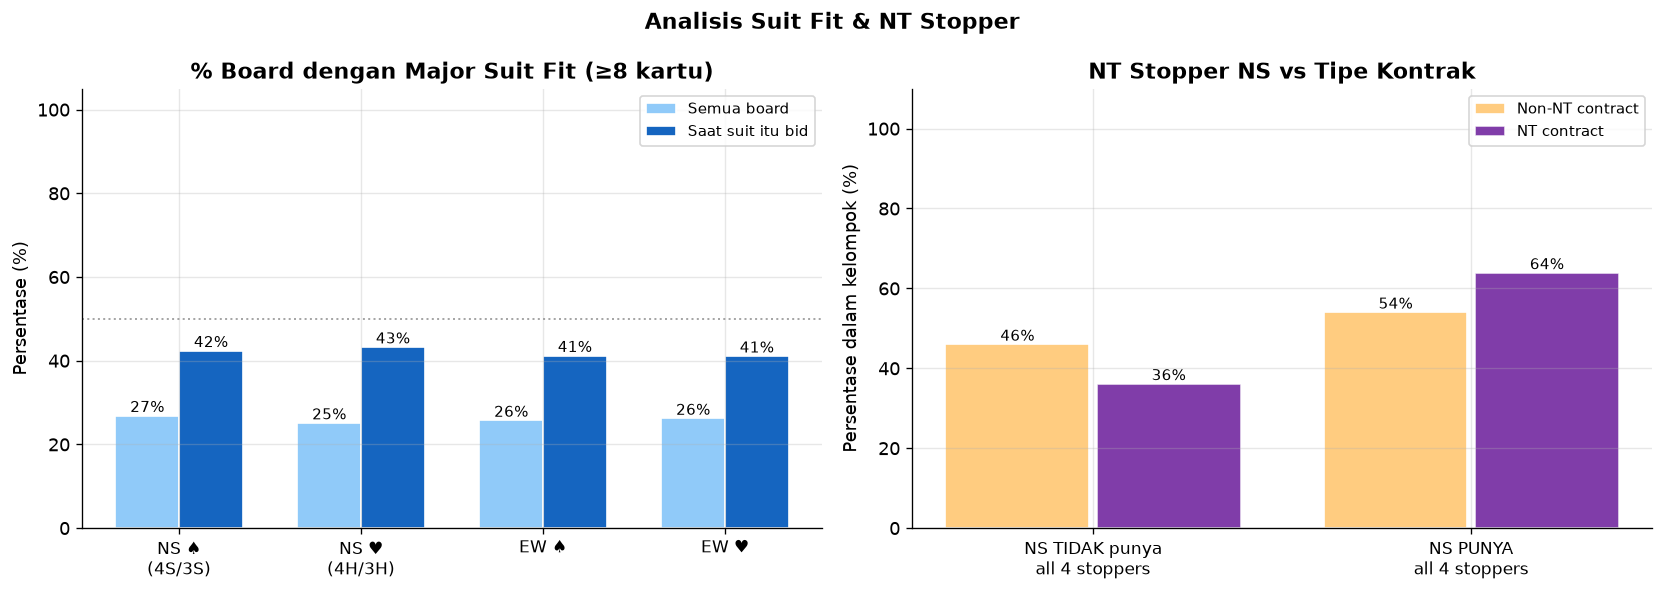


=== Detail Angka: Major Suit Fit (>=8 kartu) ===
  NS ♠ (4S/3S)    : semua board = 26.87%   |   saat suit itu dibid = 42.39%
  NS ♥ (4H/3H)    : semua board = 25.11%   |   saat suit itu dibid = 43.25%
  EW ♠            : semua board = 25.73%   |   saat suit itu dibid = 41.21%
  EW ♥            : semua board = 26.20%   |   saat suit itu dibid = 41.08%

=== Detail Angka: NT Stopper vs Tipe Kontrak ===
  Non-NT, NS TIDAK 4 stopper : 45.98%  (3,337 / 7,257 board)
  Non-NT, NS PUNYA 4 stopper : 54.02%  (3,920 / 7,257 board)
  NT,     NS TIDAK 4 stopper : 36.11%  (1,063 / 2,944 board)
  NT,     NS PUNYA 4 stopper : 63.89%  (1,881 / 2,944 board)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Major Suit Fit vs Strain ───────────────────────────────
ax = axes[0]
suit_categories = {
    'NS ♠\n(4S/3S)':  ('ns_has_fit_S', df['target_base'].str.endswith('S')),
    'NS ♥\n(4H/3H)':  ('ns_has_fit_H', df['target_base'].str.endswith('H')),
    'EW ♠':           ('ew_has_fit_S', df['target_base'].str.endswith('S')),
    'EW ♥':           ('ew_has_fit_H', df['target_base'].str.endswith('H')),
}
x_pos   = np.arange(len(suit_categories))
fit_pct_when_suit = []
fit_pct_overall   = []
for label, (fit_col, strain_mask) in suit_categories.items():
    overall  = df[fit_col].mean() * 100
    when_bid = df.loc[strain_mask, fit_col].mean() * 100
    fit_pct_overall.append(overall)
    fit_pct_when_suit.append(when_bid)

w = 0.35
bars1 = ax.bar(x_pos - w/2, fit_pct_overall,   w, label='Semua board',       color='#90CAF9', edgecolor='white')
bars2 = ax.bar(x_pos + w/2, fit_pct_when_suit, w, label='Saat suit itu bid', color='#1565C0', edgecolor='white')
ax.bar_label(bars1, fmt='%.0f%%', fontsize=9)
ax.bar_label(bars2, fmt='%.0f%%', fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(list(suit_categories.keys()), fontsize=10)
ax.axhline(50, color='gray', linestyle=':', lw=1.2, alpha=0.7)
ax.set_title('% Board dengan Major Suit Fit (≥8 kartu)', fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)

# ── NT Stopper vs NT Contract ──────────────────────────────
ax = axes[1]
nt_contracts  = df['target_base'].str.endswith('N') & (df['target_base'] != 'PASS')
non_nt        = ~nt_contracts & (df['target_base'] != 'PASS')

stopper_nt     = df.loc[nt_contracts, 'ns_nt_stoppers'].value_counts(normalize=True).sort_index() * 100
stopper_non_nt = df.loc[non_nt, 'ns_nt_stoppers'].value_counts(normalize=True).sort_index() * 100

x_s = np.array([0, 1])
ax.bar(x_s - 0.2, [stopper_non_nt.get(0,0), stopper_non_nt.get(1,0)],
       0.38, label='Non-NT contract', color='#FFCC80', edgecolor='white')
ax.bar(x_s + 0.2, [stopper_nt.get(0,0), stopper_nt.get(1,0)],
       0.38, label='NT contract', color='#6A1B9A', edgecolor='white', alpha=0.85)

ax.set_xticks([0, 1])
ax.set_xticklabels(['NS TIDAK punya\nall 4 stoppers', 'NS PUNYA\nall 4 stoppers'], fontsize=10)
ax.set_title('NT Stopper NS vs Tipe Kontrak', fontweight='bold')
ax.set_ylabel('Persentase dalam kelompok (%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=9)

plt.suptitle('Analisis Suit Fit & NT Stopper', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_fit_stopper.png', bbox_inches='tight')
plt.show()
print()
print('=== Detail Angka: Major Suit Fit (>=8 kartu) ===')
for (label, _), overall, when_bid in zip(suit_categories.items(), fit_pct_overall, fit_pct_when_suit):
    clean_label = label.replace(chr(10), ' ')
    print(f'  {clean_label:<16}: semua board = {overall:5.2f}%   |   saat suit itu dibid = {when_bid:5.2f}%')

print()
print('=== Detail Angka: NT Stopper vs Tipe Kontrak ===')
n_non_nt = non_nt.sum()
n_nt = nt_contracts.sum()
print(f'  Non-NT, NS TIDAK 4 stopper : {stopper_non_nt.get(0,0):5.2f}%  ({round(stopper_non_nt.get(0,0)/100*n_non_nt):,} / {n_non_nt:,} board)')
print(f'  Non-NT, NS PUNYA 4 stopper : {stopper_non_nt.get(1,0):5.2f}%  ({round(stopper_non_nt.get(1,0)/100*n_non_nt):,} / {n_non_nt:,} board)')
print(f'  NT,     NS TIDAK 4 stopper : {stopper_nt.get(0,0):5.2f}%  ({round(stopper_nt.get(0,0)/100*n_nt):,} / {n_nt:,} board)')
print(f'  NT,     NS PUNYA 4 stopper : {stopper_nt.get(1,0):5.2f}%  ({round(stopper_nt.get(1,0)/100*n_nt):,} / {n_nt:,} board)')


---
## 4. EDA – Losing Trick Count (LTC) & Kontrak

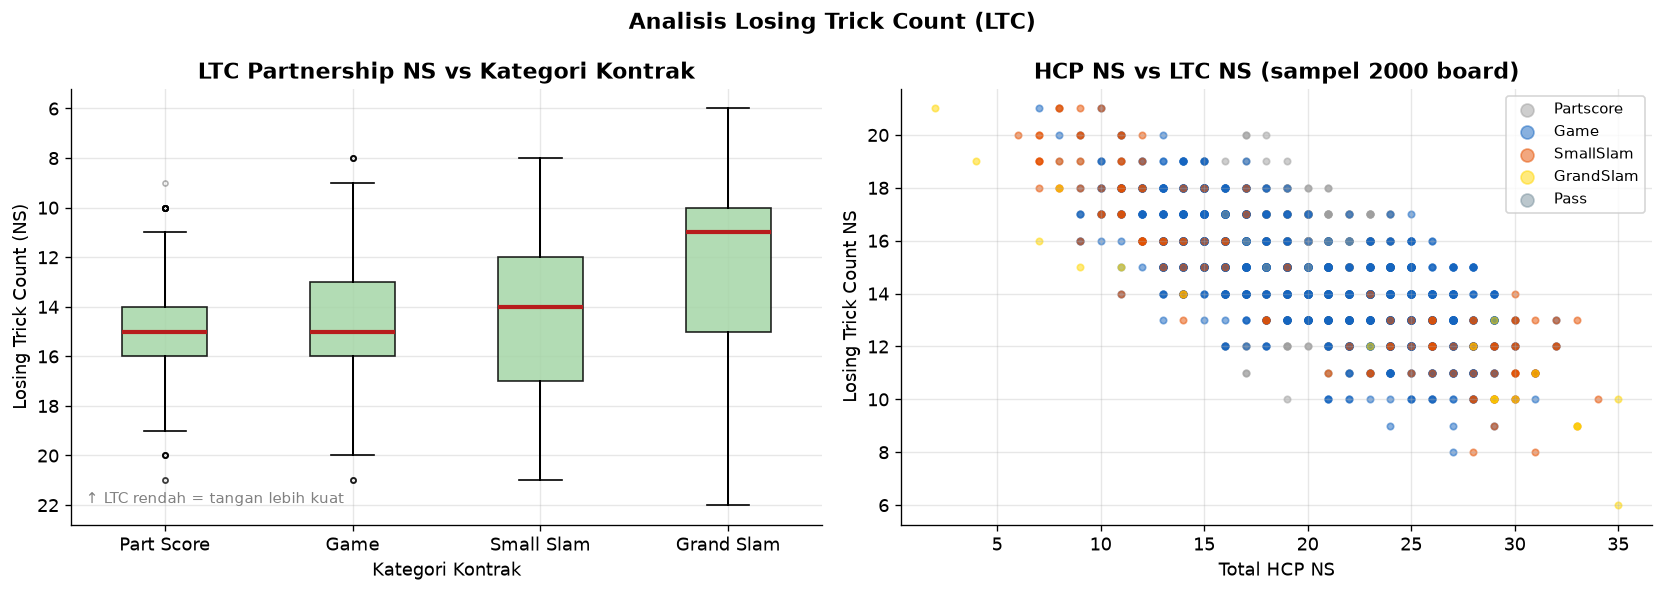


=== Detail Angka: LTC Partnership NS per Kategori Kontrak ===
                  count   mean   std   min   max
target_category                                 
Game             5512.0  14.64  2.10   8.0  21.0
GrandSlam          69.0  12.88  3.94   6.0  22.0
Partscore        3954.0  14.96  1.70   9.0  21.0
Pass               22.0  15.73  1.39  13.0  19.0
SmallSlam         666.0  14.32  3.25   8.0  21.0

Korelasi Pearson HCP NS vs LTC NS : -0.703


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── LTC NS vs kategori ────────────────────────────────────
ax = axes[0]
cat_order_ltc  = ['Partscore', 'Game', 'SmallSlam', 'GrandSlam']
cat_labels_ltc = ['Part Score', 'Game', 'Small Slam', 'Grand Slam']
ltc_data = [df[df['target_category'] == c]['ns_ltc'].dropna() for c in cat_order_ltc]

bp = ax.boxplot(
    ltc_data, tick_labels=cat_labels_ltc, patch_artist=True,
    boxprops=dict(facecolor='#A5D6A7', alpha=0.85),
    medianprops=dict(color='#B71C1C', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
)
ax.set_title('LTC Partnership NS vs Kategori Kontrak', fontweight='bold')
ax.set_xlabel('Kategori Kontrak')
ax.set_ylabel('Losing Trick Count (NS)')
ax.invert_yaxis()   # LTC rendah = tangan kuat
ax.text(0.02, 0.05, '↑ LTC rendah = tangan lebih kuat', transform=ax.transAxes,
        fontsize=9, color='gray')

# ── Scatter HCP vs LTC ────────────────────────────────────
ax = axes[1]
sample_df = df.sample(n=min(2000, len(df)), random_state=42)
cat_color_map = {
    'Partscore': '#9E9E9E', 'Game': '#1565C0',
    'SmallSlam': '#E65100', 'GrandSlam': '#FFD700', 'Pass': '#78909C',
}
for cat, color in cat_color_map.items():
    mask = sample_df['target_category'] == cat
    ax.scatter(
        sample_df.loc[mask, 'ns_hcp'],
        sample_df.loc[mask, 'ns_ltc'],
        c=color, alpha=0.5, s=15, label=cat,
    )
ax.set_title('HCP NS vs LTC NS (sampel 2000 board)', fontweight='bold')
ax.set_xlabel('Total HCP NS')
ax.set_ylabel('Losing Trick Count NS')
ax.legend(fontsize=9, markerscale=2)

plt.suptitle('Analisis Losing Trick Count (LTC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_ltc_analysis.png', bbox_inches='tight')
plt.show()
print()
print('=== Detail Angka: LTC Partnership NS per Kategori Kontrak ===')
print(df.groupby('target_category')['ns_ltc'].describe()[['count', 'mean', 'std', 'min', 'max']].round(2))

print()
corr_hcp_ltc = df['ns_hcp'].corr(df['ns_ltc'])
print(f'Korelasi Pearson HCP NS vs LTC NS : {corr_hcp_ltc:.3f}')


---
## 5. EDA – Fitur Auction

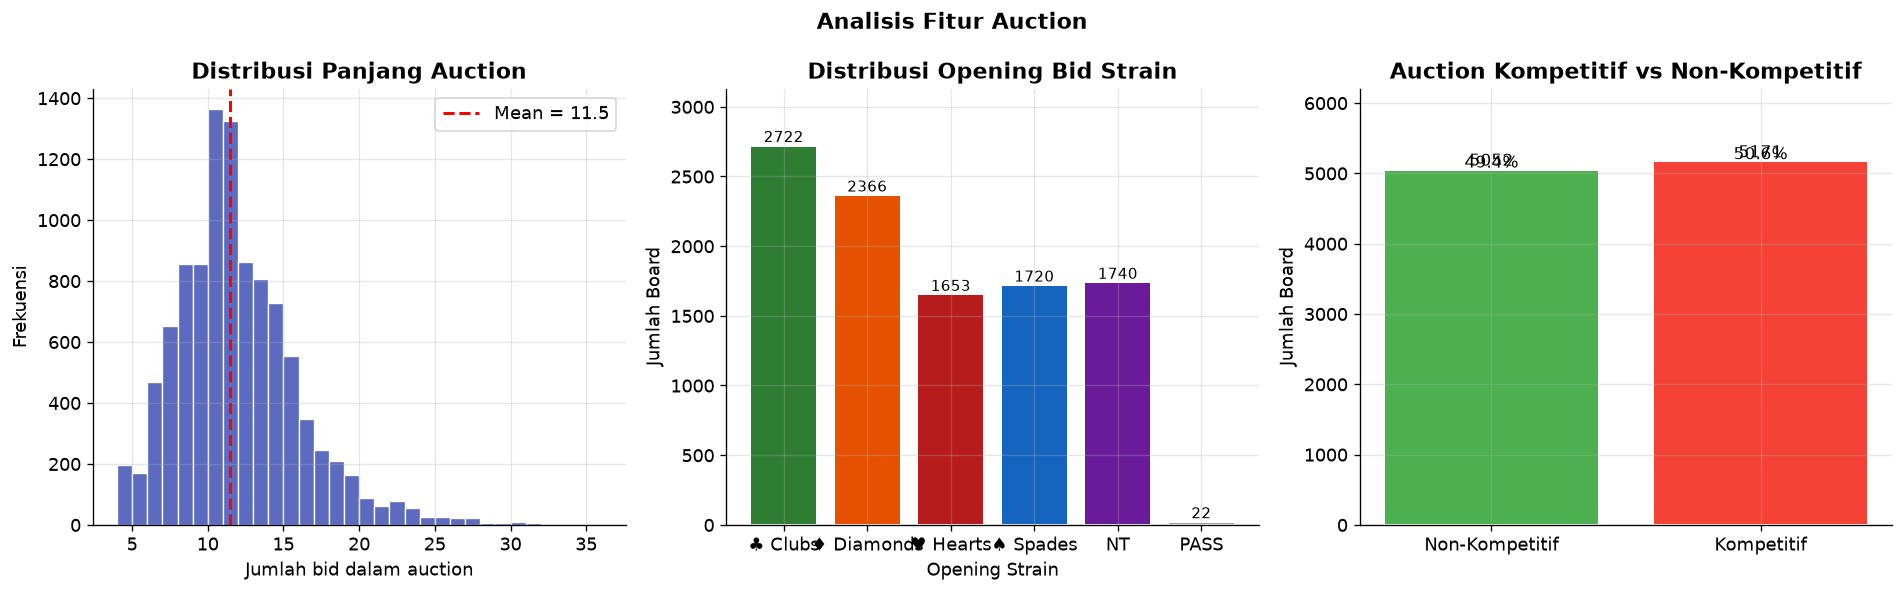


=== Detail Angka: Panjang Auction ===
count    10223.00
mean        11.47
std          4.06
min          0.00
25%          9.00
50%         11.00
75%         14.00
max         35.00
Name: auction_len, dtype: float64

=== Detail Angka: Opening Bid Strain ===
  ♣ Clubs     :  2,722  (26.63%)
  ♦ Diamonds  :  2,366  (23.14%)
  ♥ Hearts    :  1,653  (16.17%)
  ♠ Spades    :  1,720  (16.82%)
  NT          :  1,740  (17.02%)
  PASS        :     22  (0.22%)

=== Detail Angka: Auction Kompetitif vs Non-Kompetitif ===
  Non-Kompetitif  :  5,052  (49.42%)
  Kompetitif      :  5,171  (50.58%)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panjang Auction ───────────────────────────────────────
ax = axes[0]
ax.hist(df['auction_len'], bins=range(4, df['auction_len'].max()+2),
        color='#5C6BC0', edgecolor='white', linewidth=0.8)
ax.axvline(df['auction_len'].mean(), color='red', linestyle='--', lw=1.8,
           label=f'Mean = {df["auction_len"].mean():.1f}')
ax.set_title('Distribusi Panjang Auction', fontweight='bold')
ax.set_xlabel('Jumlah bid dalam auction')
ax.set_ylabel('Frekuensi')
ax.legend()

# ── Opening Strain ────────────────────────────────────────
ax = axes[1]
opening_cols = ['opening_strain_C', 'opening_strain_D', 'opening_strain_H',
                'opening_strain_S', 'opening_strain_N', 'opening_strain_PASS']
opening_labels = ['♣ Clubs', '♦ Diamonds', '♥ Hearts', '♠ Spades', 'NT', 'PASS']
opening_vals = [df[c].sum() for c in opening_cols]
oc = ['#2E7D32', '#E65100', '#B71C1C', '#1565C0', '#6A1B9A', '#9E9E9E']
bars = ax.bar(opening_labels, opening_vals, color=oc, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', fontsize=9)
ax.set_title('Distribusi Opening Bid Strain', fontweight='bold')
ax.set_xlabel('Opening Strain')
ax.set_ylabel('Jumlah Board')
ax.set_ylim(0, max(opening_vals) * 1.15)

# ── Kompetitif vs Non-Kompetitif ──────────────────────────
ax = axes[2]
comp_cnt = df['auction_competitive'].value_counts()
labels_comp = ['Non-Kompetitif', 'Kompetitif']
vals_comp   = [comp_cnt.get(0, 0), comp_cnt.get(1, 0)]
bars = ax.bar(labels_comp, vals_comp, color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', fontsize=10)
for bar, val in zip(bars, vals_comp):
    pct = val / sum(vals_comp) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{pct:.1f}%', ha='center', fontsize=10, color='black')
ax.set_title('Auction Kompetitif vs Non-Kompetitif', fontweight='bold')
ax.set_ylabel('Jumlah Board')
ax.set_ylim(0, max(vals_comp) * 1.2)

plt.suptitle('Analisis Fitur Auction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_auction_features.png', bbox_inches='tight')
plt.show()
print()
print('=== Detail Angka: Panjang Auction ===')
print(df['auction_len'].describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2))

print()
print('=== Detail Angka: Opening Bid Strain ===')
for lbl, n in zip(opening_labels, opening_vals):
    print(f'  {lbl:<12}: {n:>6,}  ({n/sum(opening_vals)*100:.2f}%)')

print()
print('=== Detail Angka: Auction Kompetitif vs Non-Kompetitif ===')
for lbl, n in zip(labels_comp, vals_comp):
    print(f'  {lbl:<16}: {n:>6,}  ({n/sum(vals_comp)*100:.2f}%)')


---
## 6. Dataset Split & Class Imbalance

In [10]:
from src.preprocessing import load_splits

df_train, df_val, df_test, feature_cols, le = load_splits(ROOT / 'data' / 'processed')

print('=== Dataset Split ===')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pct = len(split) / (len(df_train)+len(df_val)+len(df_test)) * 100
    print(f'  {name:<6}: {len(split):>5,} board  ({pct:.0f}%)')
print(f'  Total : {len(df_train)+len(df_val)+len(df_test):>5,} board')
print(f'\nKelas : {len(le.classes_)}')
print(f'Fitur : {len(feature_cols)}')

=== Dataset Split ===
  Train : 7,157 board  (70%)
  Val   : 1,533 board  (15%)
  Test  : 1,533 board  (15%)
  Total : 10,223 board

Kelas : 35
Fitur : 164


In [11]:
# Jumlah sampel per kelas untuk setiap jenis target (per split + total)
target_cols_info = [
    ('target_base', 'Kontrak dasar (PASS + level+strain)'),
    ('target_category', 'Kategori kontrak'),
    ('target', 'Kontrak + doubled/redoubled'),
]

for col, desc in target_cols_info:
    train_c = df_train[col].value_counts()
    val_c   = df_val[col].value_counts()
    test_c  = df_test[col].value_counts()
    total_c = train_c.add(val_c, fill_value=0).add(test_c, fill_value=0)

    table = pd.DataFrame({'Train': train_c, 'Val': val_c, 'Test': test_c, 'Total': total_c})
    table = table.fillna(0).astype(int).sort_values('Total', ascending=False)
    table['%'] = (table['Total'] / table['Total'].sum() * 100).round(2)

    print(f'{"="*60}')
    print(f'  {col}  —  {desc}  ({len(table)} kelas)')
    print(f'{"="*60}')
    print(table.to_string())
    print()

  target_base  —  Kontrak dasar (PASS + level+strain)  (35 kelas)
             Train  Val  Test  Total      %
target_base                                
3N            1457  314   313   2084  20.39
4S            1111  237   237   1585  15.50
4H             946  201   203   1350  13.21
2S             400   84    85    569   5.57
1N             390   84    84    558   5.46
2H             302   64    64    430   4.21
3S             273   60    59    392   3.83
3H             270   60    59    389   3.81
3C             199   44    43    286   2.80
3D             198   42    42    282   2.76
5C             176   37    36    249   2.44
5D             171   36    37    244   2.39
6S             162   36    35    233   2.28
2D             132   29    27    188   1.84
5H             123   27    27    177   1.73
2N             115   24    25    164   1.60
6H             109   22    22    153   1.50
2C              71   17    16    104   1.02
5S              72   15    15    102   1.00
6D        

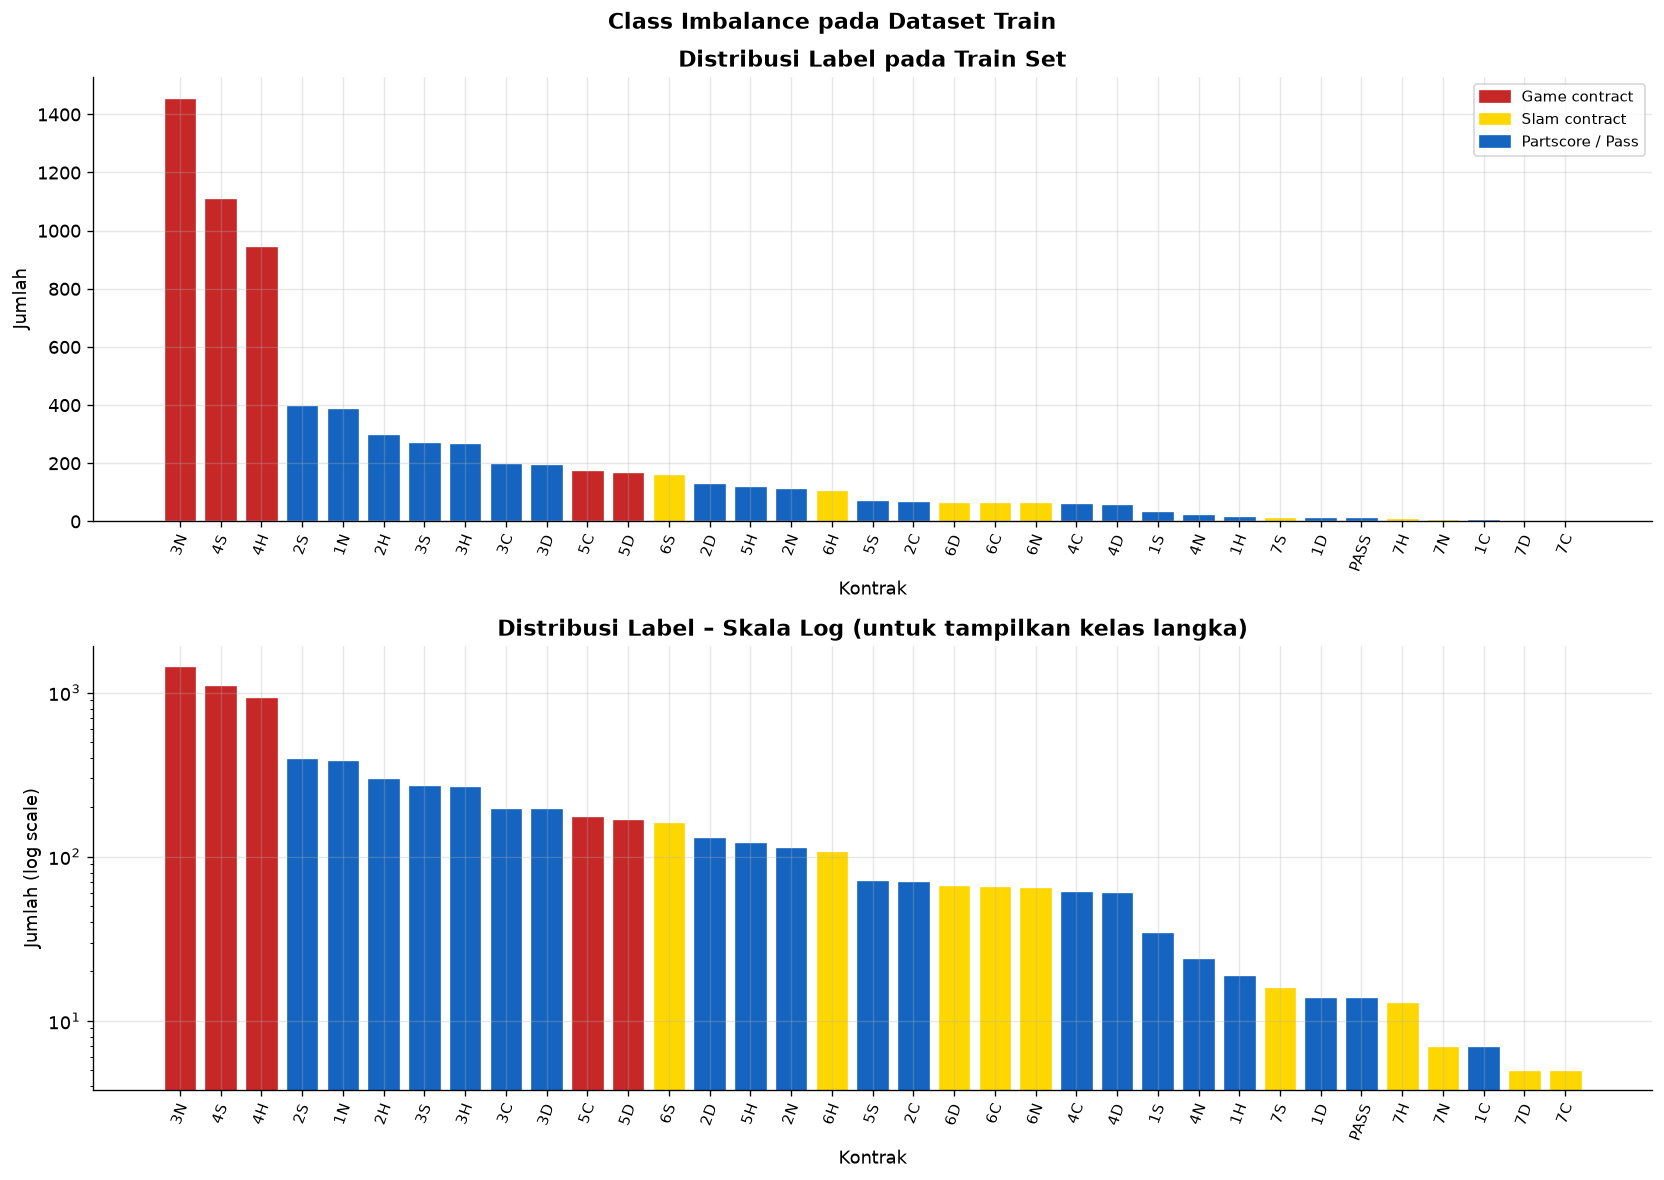


Kelas terbanyak : 3N  (1,457)
Kelas tersedikit: 7C (5)
Rasio imbalance : 291x


In [12]:
# Visualisasi distribusi label
label_counts = df_train['target_base'].value_counts()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Bar chart semua kelas ──────────────────────────────────
ax = axes[0]
game_set = {'3N', '4S', '4H', '5D', '5C'}
slam_set = {c for c in label_counts.index if c[0] in '67'}
bar_colors = [
    '#C62828' if c in game_set else
    '#FFD700' if c in slam_set else
    '#1565C0' for c in label_counts.index
]
bars = ax.bar(label_counts.index, label_counts.values,
              color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_title('Distribusi Label pada Train Set', fontweight='bold')
ax.set_xlabel('Kontrak')
ax.set_ylabel('Jumlah')
ax.tick_params(axis='x', rotation=70, labelsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#C62828', label='Game contract'),
    Patch(color='#FFD700', label='Slam contract'),
    Patch(color='#1565C0', label='Partscore / Pass'),
], fontsize=9)

# ── Log scale untuk tampilkan kelas langka ─────────────────
ax = axes[1]
ax.bar(label_counts.index, label_counts.values,
       color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_yscale('log')
ax.set_title('Distribusi Label – Skala Log (untuk tampilkan kelas langka)', fontweight='bold')
ax.set_xlabel('Kontrak')
ax.set_ylabel('Jumlah (log scale)')
ax.tick_params(axis='x', rotation=70, labelsize=9)

plt.suptitle('Class Imbalance pada Dataset Train', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'nb02_class_imbalance.png', bbox_inches='tight')
plt.show()

print(f'\nKelas terbanyak : {label_counts.index[0]}  ({label_counts.iloc[0]:,})')
print(f'Kelas tersedikit: {label_counts.index[-1]} ({label_counts.iloc[-1]:,})')
print(f'Rasio imbalance : {label_counts.iloc[0] / label_counts.iloc[-1]:.0f}x')

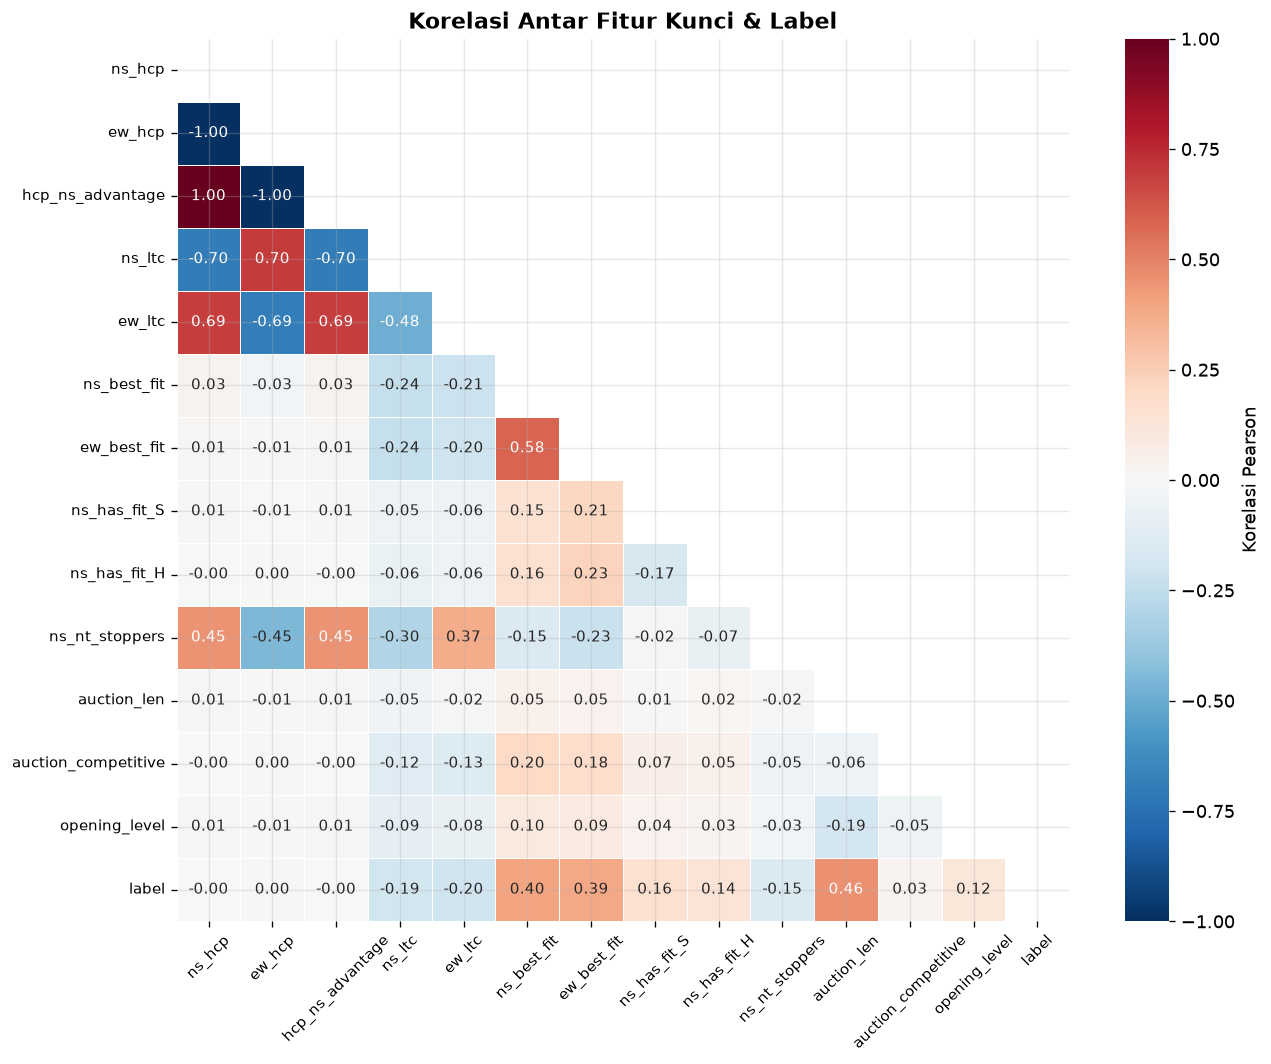


=== Detail Angka: Matriks Korelasi Pearson ===
                     ns_hcp  ew_hcp  hcp_ns_advantage  ns_ltc  ew_ltc  ns_best_fit  ew_best_fit  ns_has_fit_S  ns_has_fit_H  ns_nt_stoppers  auction_len  auction_competitive  opening_level  label
ns_hcp                1.000  -1.000             1.000  -0.703   0.693        0.035        0.008         0.007        -0.004           0.450        0.013               -0.005          0.013 -0.004
ew_hcp               -1.000   1.000            -1.000   0.703  -0.693       -0.035       -0.008        -0.007         0.004          -0.450       -0.013                0.005         -0.013  0.004
hcp_ns_advantage      1.000  -1.000             1.000  -0.703   0.693        0.035        0.008         0.007        -0.004           0.450        0.013               -0.005          0.013 -0.004
ns_ltc               -0.703   0.703            -0.703   1.000  -0.484       -0.237       -0.238        -0.049        -0.063          -0.302       -0.047               -

: 

In [ ]:
# Korelasi fitur-fitur kunci dengan label numerik
key_features = [
    'ns_hcp', 'ew_hcp', 'hcp_ns_advantage',
    'ns_ltc', 'ew_ltc',
    'ns_best_fit', 'ew_best_fit',
    'ns_has_fit_S', 'ns_has_fit_H',
    'ns_nt_stoppers',
    'auction_len', 'auction_competitive',
    'opening_level',
]

corr_df = df[key_features + ['label']].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Korelasi Pearson'},
    ax=ax, annot_kws={'size': 9},
)
ax.set_title('Korelasi Antar Fitur Kunci & Label', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(OUT / 'nb02_correlation.png', bbox_inches='tight')
plt.show()
print()
print('=== Detail Angka: Matriks Korelasi Pearson ===')
print(corr_df.round(3).to_string())


---
## Ringkasan Notebook 2

**Temuan EDA:**
- **HCP** adalah prediktor utama — makin tinggi HCP NS, makin besar kemungkinan kontrak tinggi
- **Suit Fit (≥8 kartu)** sangat berkorelasi dengan kontrak major suit (4S, 4H)
- **NT Stopper** — 80%+ kontrak NT dimainkan oleh NS yang punya stopper di semua 4 suit
- **LTC** berbanding terbalik dengan level kontrak
- **Class imbalance** cukup ekstrem: 3N=20%, Grand Slam <1%
- **Auction kompetitif** terjadi pada 54% board

**Dataset:**
- 164 fitur numerik/biner (tidak perlu encoding tambahan)
- Train 70% / Val 15% / Test 15% — split non-stratified karena ada kelas dengan 1 sampel

**Lanjut ke:** `03_modeling.ipynb` → Training RF, XGBoost, LightGBM